# 01 — Data Profiling

**Mục tiêu:** Trước khi bắt đầu MCQ / EDA / Forecasting, phải hiểu data:
1. Load tất cả 14 CSV → check shape, dtypes
2. Phân tích null values
3. Validate primary keys (duplicates)
4. Validate foreign key relationships (orphan records)
5. Validate business constraints (`cogs < price`)
6. Date ranges của mỗi bảng
7. Categorical value distributions

→ Output: hiểu rõ data trước khi animal làm gì khác.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Path đến data — notebook nằm trong notebooks/, data nằm trong ../data/raw/
DATA_DIR = Path('../data/raw')
assert DATA_DIR.exists(), f'Không tìm thấy {DATA_DIR.resolve()}. Hãy đặt CSV vào data/raw/'

print(f'Data dir: {DATA_DIR.resolve()}')
print('Files found:')
for f in sorted(DATA_DIR.glob('*.csv')):
    print(f'  {f.name}  ({f.stat().st_size / 1024:,.0f} KB)')

Data dir: /Users/minhob/MinhOB/Datathon/data/raw
Files found:
  customers.csv  (6,914 KB)
  geography.csv  (1,369 KB)
  inventory.csv  (5,536 KB)
  order_items.csv  (23,382 KB)
  orders.csv  (44,886 KB)
  payments.csv  (17,952 KB)
  products.csv  (191 KB)
  promotions.csv  (4 KB)
  returns.csv  (2,228 KB)
  reviews.csv  (6,632 KB)
  sales.csv  (127 KB)
  sample_submission.csv  (18 KB)
  shipments.csv  (19,293 KB)
  web_traffic.csv  (204 KB)


## 2. Load tất cả 14 file CSV

In [2]:
FILES = {
    # Master
    'products': 'products.csv',
    'customers': 'customers.csv',
    'promotions': 'promotions.csv',
    'geography': 'geography.csv',
    # Transaction
    'orders': 'orders.csv',
    'order_items': 'order_items.csv',
    'payments': 'payments.csv',
    'shipments': 'shipments.csv',
    'returns': 'returns.csv',
    'reviews': 'reviews.csv',
    # Analytical
    'sales': 'sales.csv',
    'sample_submission': 'sample_submission.csv',
    # Operational
    'inventory': 'inventory.csv',
    'web_traffic': 'web_traffic.csv',
}

dfs = {}
for name, fname in FILES.items():
    path = DATA_DIR / fname
    if path.exists():
        dfs[name] = pd.read_csv(path)
        print(f'✓ {name:20s} {dfs[name].shape[0]:>10,} rows × {dfs[name].shape[1]:>2} cols')
    else:
        print(f'✗ {fname} — KHÔNG TÌM THẤY')

✓ products                  2,412 rows ×  8 cols
✓ customers               121,930 rows ×  7 cols
✓ promotions                   50 rows × 10 cols
✓ geography                39,948 rows ×  4 cols
✓ orders                  646,945 rows ×  8 cols
✓ order_items             714,669 rows ×  7 cols
✓ payments                646,945 rows ×  4 cols
✓ shipments               566,067 rows ×  4 cols
✓ returns                  39,939 rows ×  7 cols
✓ reviews                 113,551 rows ×  7 cols
✓ sales                     3,833 rows ×  3 cols
✓ sample_submission           548 rows ×  3 cols
✓ inventory                60,247 rows × 17 cols
✓ web_traffic               3,652 rows ×  7 cols


## 3. Quick overview — dtypes & head

In [3]:
for name, df in dfs.items():
    print(f'\n{"="*70}')
    print(f'  {name}  —  {df.shape[0]:,} rows × {df.shape[1]} cols')
    print(f'{"="*70}')
    print(df.dtypes.to_string())
    print('--- head(3) ---')
    print(df.head(3).to_string())


  products  —  2,412 rows × 8 cols
product_id        int64
product_name        str
category            str
segment             str
size                str
color               str
price           float64
cogs            float64
--- head(3) ---
   product_id      product_name    category   segment size   color     price      cogs
0         536  SaigonFlex UC-01  Streetwear  Everyday    S   green 11,059.65  9,704.84
1         537  SaigonFlex UC-02  Streetwear  Everyday    M  silver  9,523.08  5,393.87
2         538  SaigonFlex UC-03  Streetwear  Everyday    L    pink 15,951.63 11,371.92

  customers  —  121,930 rows × 7 cols
customer_id            int64
zip                    int64
city                     str
signup_date              str
gender                   str
age_group                str
acquisition_channel      str
--- head(3) ---
   customer_id    zip       city signup_date  gender age_group acquisition_channel
0            1  15201  Hai Phong  2021-12-30  Female     35-44     

## 4. Null analysis

Theo đề bài, một số cột được phép null (gender, age_group, acquisition_channel, applicable_category, ...). Ta cần biết tỷ lệ null thực tế.

In [4]:
for name, df in dfs.items():
    nulls = df.isna().sum()
    nulls = nulls[nulls > 0].sort_values(ascending=False)
    if len(nulls) > 0:
        print(f'\n{name}:')
        for col, n in nulls.items():
            pct = n / len(df) * 100
            print(f'  {col:30s} {n:>10,}  ({pct:5.1f}%)')
    else:
        print(f'{name}: không có null')

products: không có null
customers: không có null

promotions:
  applicable_category                    40  ( 80.0%)
geography: không có null
orders: không có null

order_items:
  promo_id_2                        714,463  (100.0%)
  promo_id                          438,353  ( 61.3%)
payments: không có null
shipments: không có null
returns: không có null
reviews: không có null
sales: không có null
sample_submission: không có null
inventory: không có null
web_traffic: không có null


## 5. Validate Primary Keys (duplicates)

In [5]:
PK_CHECKS = {
    'products':   'product_id',
    'customers':  'customer_id',
    'promotions': 'promo_id',
    'geography':  'zip',
    'orders':     'order_id',
    'returns':    'return_id',
    'reviews':    'review_id',
}

print(f'{"Table.PK":<35} {"Duplicates":>12}  Status')
print('-' * 65)
for name, pk in PK_CHECKS.items():
    dup = dfs[name][pk].duplicated().sum()
    status = '⚠️  VIOLATION' if dup > 0 else '✓ OK'
    print(f'{name + "." + pk:<35} {dup:>12,}  {status}')

Table.PK                              Duplicates  Status
-----------------------------------------------------------------
products.product_id                            0  ✓ OK
customers.customer_id                          0  ✓ OK
promotions.promo_id                            0  ✓ OK
geography.zip                                  0  ✓ OK
orders.order_id                                0  ✓ OK
returns.return_id                              0  ✓ OK
reviews.review_id                              0  ✓ OK


## 6. Validate Foreign Key relationships

Kiểm tra orphan records — bản ghi tham chiếu đến PK không tồn tại.

In [6]:
FK_CHECKS = [
    # (child_table, child_col, parent_table, parent_col)
    ('customers',   'zip',         'geography',  'zip'),
    ('orders',      'customer_id', 'customers',  'customer_id'),
    ('orders',      'zip',         'geography',  'zip'),
    ('order_items', 'order_id',    'orders',     'order_id'),
    ('order_items', 'product_id',  'products',   'product_id'),
    ('payments',    'order_id',    'orders',     'order_id'),
    ('shipments',   'order_id',    'orders',     'order_id'),
    ('returns',     'order_id',    'orders',     'order_id'),
    ('returns',     'product_id',  'products',   'product_id'),
    ('reviews',     'order_id',    'orders',     'order_id'),
    ('reviews',     'product_id',  'products',   'product_id'),
    ('reviews',     'customer_id', 'customers',  'customer_id'),
    ('inventory',   'product_id',  'products',   'product_id'),
]

print(f'{"Child → Parent":<55} {"Orphans":>10}  Status')
print('-' * 80)
for child, ckey, parent, pkey in FK_CHECKS:
    cdf, pdf = dfs[child], dfs[parent]
    parent_keys = set(pdf[pkey].dropna().unique())
    orphans = cdf[~cdf[ckey].isin(parent_keys) & cdf[ckey].notna()]
    n = len(orphans)
    status = '⚠️  ORPHANS' if n > 0 else '✓ OK'
    label = f'{child}.{ckey} → {parent}.{pkey}'
    print(f'{label:<55} {n:>10,}  {status}')

Child → Parent                                             Orphans  Status
--------------------------------------------------------------------------------
customers.zip → geography.zip                                    0  ✓ OK
orders.customer_id → customers.customer_id                       0  ✓ OK
orders.zip → geography.zip                                       0  ✓ OK
order_items.order_id → orders.order_id                           0  ✓ OK
order_items.product_id → products.product_id                     0  ✓ OK
payments.order_id → orders.order_id                              0  ✓ OK
shipments.order_id → orders.order_id                             0  ✓ OK
returns.order_id → orders.order_id                               0  ✓ OK
returns.product_id → products.product_id                         0  ✓ OK
reviews.order_id → orders.order_id                               0  ✓ OK
reviews.product_id → products.product_id                         0  ✓ OK
reviews.customer_id → customers.customer_

## 7. Business constraints

Đề bài: `cogs < price` với mọi sản phẩm.

In [7]:
p = dfs['products']
violations = (p['cogs'] >= p['price']).sum()
print(f'products.cogs >= price: {violations} violations  ' + ('⚠️' if violations > 0 else '✓'))

# Margin distribution
margin = (p['price'] - p['cogs']) / p['price']
print(f'\nGross margin distribution:')
print(margin.describe().to_string())

# Margin theo segment (preview cho Q2 MCQ)
print(f'\nMargin TB theo segment (Q2 MCQ preview):')
p['margin'] = margin
print(p.groupby('segment')['margin'].mean().sort_values(ascending=False).to_string())

products.cogs >= price: 0 violations  ✓

Gross margin distribution:
count   2,412.00
mean        0.27
std         0.15
min         0.05
25%         0.10
50%         0.31
75%         0.40
max         0.50

Margin TB theo segment (Q2 MCQ preview):
segment
Standard      0.31
Premium       0.29
All-weather   0.28
Activewear    0.27
Performance   0.26
Balanced      0.26
Trendy        0.24
Everyday      0.24


## 8. Date ranges

In [8]:
DATE_COLS = {
    'customers':   ['signup_date'],
    'promotions':  ['start_date', 'end_date'],
    'orders':      ['order_date'],
    'shipments':   ['ship_date', 'delivery_date'],
    'returns':     ['return_date'],
    'reviews':     ['review_date'],
    'sales':       ['Date'],
    'inventory':   ['snapshot_date'],
    'web_traffic': ['date'],
}

print(f'{"Table.col":<35} {"Min":<14} {"Max":<14} {"Non-null":>10}')
print('-' * 80)
for name, cols in DATE_COLS.items():
    df = dfs[name]
    for c in cols:
        d = pd.to_datetime(df[c], errors='coerce')
        label = f'{name}.{c}'
        print(f'{label:<35} {str(d.min().date()):<14} {str(d.max().date()):<14} {d.notna().sum():>10,}')

Table.col                           Min            Max              Non-null
--------------------------------------------------------------------------------
customers.signup_date               2012-01-17     2022-12-31        121,930
promotions.start_date               2013-01-31     2022-11-18             50
promotions.end_date                 2013-03-01     2022-12-31             50
orders.order_date                   2012-07-04     2022-12-31        646,945
shipments.ship_date                 2012-07-04     2022-12-29        566,067
shipments.delivery_date             2012-07-06     2022-12-31        566,067
returns.return_date                 2012-07-11     2022-12-31         39,939
reviews.review_date                 2012-07-10     2022-12-31        113,551
sales.Date                          2012-07-04     2022-12-31          3,833
inventory.snapshot_date             2012-07-31     2022-12-31         60,247
web_traffic.date                    2013-01-01     2022-12-31          3

## 9. Categorical distributions

Liệt kê các giá trị unique của cột categorical — quan trọng để hiểu domain.

In [9]:
CAT_COLS = {
    'products':    ['category', 'segment', 'size', 'color'],
    'customers':   ['gender', 'age_group', 'acquisition_channel'],
    'orders':      ['order_status', 'payment_method', 'device_type', 'order_source'],
    'promotions':  ['promo_type', 'promo_channel', 'applicable_category', 'stackable_flag'],
    'returns':     ['return_reason'],
    'web_traffic': ['traffic_source'],
    'geography':   ['region'],
    'payments':    ['payment_method', 'installments'],
}

for name, cols in CAT_COLS.items():
    df = dfs[name]
    for c in cols:
        if c not in df.columns:
            continue
        vc = df[c].value_counts(dropna=False)
        print(f'\n--- {name}.{c}  (unique = {df[c].nunique(dropna=True)}) ---')
        print(vc.head(15).to_string())


--- products.category  (unique = 4) ---
category
Streetwear    1320
Outdoor        743
Casual         201
GenZ           148

--- products.segment  (unique = 8) ---
segment
Activewear     598
Everyday       405
Performance    347
Balanced       306
Standard       262
Premium        177
All-weather    169
Trendy         148

--- products.size  (unique = 4) ---
size
S     603
M     603
L     603
XL    603

--- products.color  (unique = 10) ---
color
black     242
orange    242
green     241
silver    241
pink      241
yellow    241
red       241
blue      241
white     241
purple    241

--- customers.gender  (unique = 3) ---
gender
Female        59640
Male          57457
Non-binary     4833

--- customers.age_group  (unique = 5) ---
age_group
25-34    36342
35-44    31920
45-54    23172
18-24    17039
55+      13457

--- customers.acquisition_channel  (unique = 6) ---
acquisition_channel
organic_search    36450
social_media      24448
paid_search       24285
email_campaign    14674
ref

## 10. Sales — preview tập train

File chính cho Phần 3 — kiểm tra range, missing dates, basic stats.

Sales shape: (3833, 3)
Date range: 2012-07-04 → 2022-12-31
Expected days: 3,833  |  Actual: 3,833  |  Missing: 0

Revenue & COGS describe:
            Revenue          COGS
count      3,833.00      3,833.00
mean   4,286,584.03  3,695,134.49
std    2,624,840.20  2,219,788.77
min      279,813.94    236,576.31
25%    2,471,088.82  2,150,580.23
50%    3,647,303.90  3,161,112.99
75%    5,350,877.20  4,637,293.92
max   20,905,271.35 16,535,857.67


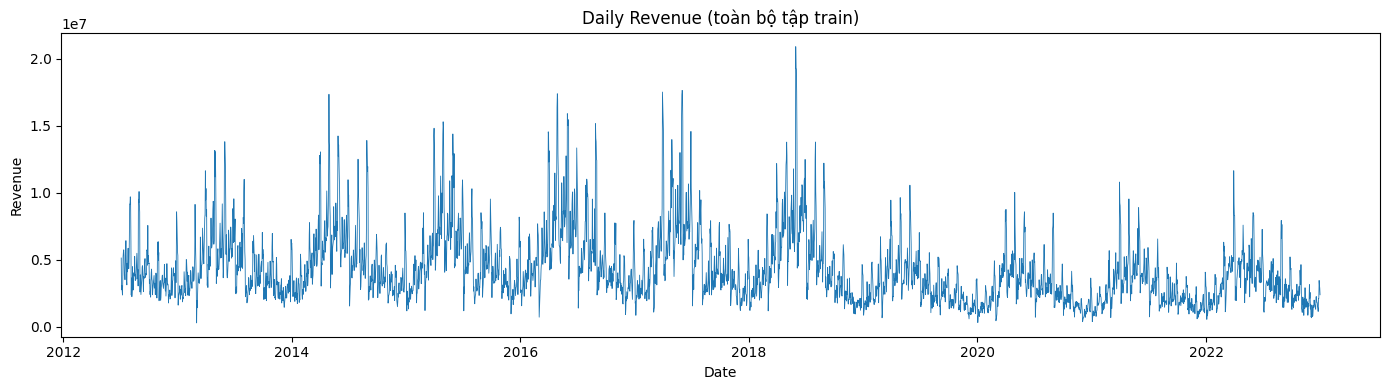

In [10]:
s = dfs['sales'].copy()
s['Date'] = pd.to_datetime(s['Date'])
s = s.sort_values('Date').reset_index(drop=True)

print(f'Sales shape: {s.shape}')
print(f'Date range: {s.Date.min().date()} → {s.Date.max().date()}')

expected = pd.date_range(s.Date.min(), s.Date.max(), freq='D')
missing = set(expected) - set(s.Date)
print(f'Expected days: {len(expected):,}  |  Actual: {len(s):,}  |  Missing: {len(missing):,}')

print(f'\nRevenue & COGS describe:')
print(s[['Revenue', 'COGS']].describe().to_string())

# Quick visual
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(s['Date'], s['Revenue'], lw=0.6)
ax.set_title('Daily Revenue (toàn bộ tập train)')
ax.set_xlabel('Date'); ax.set_ylabel('Revenue')
plt.tight_layout()
plt.show()

## 11. Sample submission — định dạng nộp Kaggle

In [11]:
ss = dfs['sample_submission']
print(f'Sample submission shape: {ss.shape}')
print(f'Columns: {list(ss.columns)}')
print(f'\nHead:')
print(ss.head().to_string())
print(f'\nTail:')
print(ss.tail().to_string())

if 'Date' in ss.columns:
    ss_dates = pd.to_datetime(ss['Date'])
    print(f'\nTest date range: {ss_dates.min().date()} → {ss_dates.max().date()}')
    print(f'Số ngày test: {len(ss):,}')

Sample submission shape: (548, 3)
Columns: ['Date', 'Revenue', 'COGS']

Head:
         Date      Revenue         COGS
0  2023-01-01 2,665,507.20 2,518,885.15
1  2023-01-02 1,280,007.89 1,136,463.00
2  2023-01-03 1,015,899.51   822,721.12
3  2023-01-04 1,142,997.27   914,554.18
4  2023-01-05 1,236,312.34   984,390.24

Tail:
           Date      Revenue         COGS
543  2024-06-27 4,111,585.95 4,048,492.76
544  2024-06-28 4,591,751.39 4,504,603.05
545  2024-06-29 6,582,807.93 6,478,608.03
546  2024-06-30 5,484,749.90 5,386,065.13
547  2024-07-01 5,057,610.99 4,989,753.02

Test date range: 2023-01-01 → 2024-07-01
Số ngày test: 548


## 12. Checklist sau khi chạy

Sau khi run All notebook này, ta cần ghi nhận vào `data_summary.md` (manual) các điểm sau:

- [ ] Tất cả 14 file load được không? Nếu thiếu → check Kaggle download
- [ ] Có table nào có duplicate PK không? → cần xử lý trước khi join
- [ ] Có FK orphans nào không? → ghi nhận để filter khi join
- [ ] `cogs < price` 100% — pass?
- [ ] Sales có thiếu ngày nào không? → cần fill khi forecasting
- [ ] Test set có range đúng `01/01/2023 → 01/07/2024`?
- [ ] Số ngày test = ? (để biết shape submission)
- [ ] Categorical values có gì bất thường (typo, casing inconsistency)?

Sau bước này → có thể tự tin bắt đầu Phần 1 (MCQ).